# OmicSieve TP53 Baseline With Fold-Wise Feature Selection

This notebook evaluates a TP53 mutation-prediction baseline using two univariate feature-selection metrics: `f_classif` and `mutual_info_classif`.

Feature selection is fit only on the training split inside each fold of 5-fold cross-validation, and the same no-leakage pattern is used for the holdout evaluation.

In [23]:
from pathlib import Path
from functools import partial
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

In [24]:
DATA_DIR = Path('/media/storage/Amir/Dataset/Deep Mut/')
MUT_INFO_PATH = DATA_DIR / 'mut_info.tsv'
RNASEQ_PATH = DATA_DIR / 'rnaseq_data.tsv'
META_PATH = DATA_DIR / 'meta_data.tsv'

meta_df = pd.read_csv(META_PATH, sep='\t')
header_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, nrows=1, dtype=str)
gene_names = header_df.iloc[0, :].tolist()
rnaseq_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, skiprows=1, dtype=str, engine='python', on_bad_lines='warn')

if rnaseq_df.shape[1] > len(gene_names):
    rnaseq_df = rnaseq_df.iloc[:, :len(gene_names)]
elif rnaseq_df.shape[1] < len(gene_names):
    for _ in range(len(gene_names) - rnaseq_df.shape[1]):
        rnaseq_df[len(rnaseq_df.columns)] = None

rnaseq_df.columns = gene_names
rnaseq_df = rnaseq_df.rename(columns={gene_names[0]: 'sample_id'})
print(f'RNA-seq shape: {rnaseq_df.shape}')


RNA-seq shape: (9626, 19311)


In [25]:
def _clean_meta(df: pd.DataFrame) -> pd.DataFrame:
    meta = df.copy()
    meta.columns = (
        meta.columns.astype(str)
        .str.strip()
        .str.strip('"')
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    if 'sample' in meta.columns:
        meta['patient_id'] = meta['sample'].astype(str).str.strip().str.replace('"', '')
    meta = meta.dropna(subset=['patient_id']).drop_duplicates('patient_id')
    return meta


def _clean_rnaseq(df: pd.DataFrame) -> pd.DataFrame:
    gnames = df.columns.astype(str).str.strip().str.replace('"', '')
    sample_ids = df.iloc[:, 0].astype(str).str.strip().str.replace('"', '')
    expr_data = df.iloc[:, 1:].copy()
    expr_data.columns = gnames[:len(expr_data.columns)]
    expr_data = expr_data.apply(pd.to_numeric, errors='coerce')
    rna_clean = pd.concat([sample_ids.reset_index(drop=True), expr_data.reset_index(drop=True)], axis=1)
    rna_clean.columns = ['patient_id'] + list(expr_data.columns)
    rna_clean = rna_clean[rna_clean['patient_id'].str.len() > 0].dropna(subset=['patient_id'])
    rna_clean = rna_clean.set_index('patient_id')
    rna_final = rna_clean.groupby(level=0).mean()
    rna_final = rna_final.T
    rna_final['gene_id'] = rna_final.index
    rna_final = rna_final[['gene_id'] + [c for c in rna_final.columns if c != 'gene_id']]
    rna_final = rna_final.reset_index(drop=True)
    return rna_final


clean_meta_df = _clean_meta(meta_df)
clean_rnaseq_df = _clean_rnaseq(rnaseq_df)
rnaseq_patient_ids = set(clean_rnaseq_df.columns) - {'gene_id'}
matched_patient_ids = sorted(set(clean_meta_df['patient_id']) & rnaseq_patient_ids)
clean_meta_df = clean_meta_df[clean_meta_df['patient_id'].isin(matched_patient_ids)].reset_index(drop=True)
clean_rnaseq_df = clean_rnaseq_df[['gene_id'] + matched_patient_ids]

mut_df = pd.read_csv(MUT_INFO_PATH, sep='	', dtype=str)
mut_df.columns = (
    mut_df.columns.astype(str)
    .str.strip()
    .str.strip('"')
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

index_ids = pd.Index(mut_df.index).astype(str)
index_tcga_fraction = index_ids.str.match(r'^TCGA-[A-Z0-9]+-[A-Z0-9]+-\d+').mean()
if index_tcga_fraction > 0.5:
    mut_df = mut_df.copy()
    mut_df['patient_id'] = index_ids.str.strip().str.replace('"', '')
    id_col = 'patient_id'
else:
    id_candidates = ['patient_id', 'sample', 'x_patient', 'rnaseqid', 'sample_id', 'mutid']
    id_col = next((c for c in id_candidates if c in mut_df.columns), mut_df.columns[0])
    mut_df[id_col] = mut_df[id_col].astype(str).str.strip().str.replace('"', '')

mut_df = mut_df.dropna(subset=[id_col]).drop_duplicates(id_col)
mutation_cols = [c for c in mut_df.columns if c != id_col]
tp53_col = next((c for c in mutation_cols if 'tp53' in c.lower()), None)

binary_mut_info = mut_df[[id_col, tp53_col]].copy()
binary_mut_info['mutation_label'] = binary_mut_info[tp53_col].apply(
    lambda x: 0 if str(x).strip().lower() == 'wild' else 1
)

mutation_by_patient = binary_mut_info.set_index(id_col)['mutation_label']
clean_meta_df['mutation_label'] = clean_meta_df['patient_id'].map(mutation_by_patient)
valid_idx = clean_meta_df['mutation_label'].notna()
labeled_meta_df = clean_meta_df[valid_idx].copy().reset_index(drop=True)
labeled_meta_df['mutation_label'] = labeled_meta_df['mutation_label'].astype(int)

ordered_patient_ids = sorted(set(labeled_meta_df['patient_id']) & rnaseq_patient_ids)
labeled_meta_df = labeled_meta_df.set_index('patient_id').loc[ordered_patient_ids].reset_index()
labeled_rnaseq_df = clean_rnaseq_df[['gene_id'] + ordered_patient_ids].reset_index(drop=True)

X_raw = labeled_rnaseq_df.drop(columns='gene_id').T.to_numpy(dtype=float)
y_binary = labeled_meta_df['mutation_label'].astype(int).to_numpy()
feature_names = labeled_rnaseq_df['gene_id'].astype(str).tolist()

assert X_raw.shape[0] == y_binary.shape[0] == len(ordered_patient_ids)

print(f'Found TP53 column: {tp53_col}')
print(f'Labeled metadata: {labeled_meta_df.shape}')
print(f'Labeled RNA-seq: {labeled_rnaseq_df.shape}')
print(pd.Series(y_binary).value_counts().sort_index())
print(f'Feature count before selection: {len(feature_names)}')


Found TP53 column: gene.tp53
Labeled metadata: (9626, 42)
Labeled RNA-seq: (19310, 9627)
0    6036
1    3590
Name: count, dtype: int64
Feature count before selection: 19310


In [26]:
def prepare_raw_data(X, y, test_size=0.15, val_size=0.15, random_state=42):
    splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(splitter1.split(X, y))

    X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    val_size_adjusted = val_size / (1.0 - test_size)
    splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
    train_idx, val_idx = next(splitter2.split(X_train_val, y_train_val))

    X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
    X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
    }

data = prepare_raw_data(X_raw, y_binary)
print(data['X_train'].shape, data['X_val'].shape, data['X_test'].shape)

(6738, 19310) (1444, 19310) (1444, 19310)


In [27]:
FEATURE_SELECTION_METHODS = {
    'anova_f': f_classif,
    'mutual_info': partial(mutual_info_classif, random_state=42),
}
TOP_K =50

def build_xgb_classifier(scale_pos_weight, random_state=42):
    return xgb.XGBClassifier(
        n_estimators=350,
        max_depth=8,
        learning_rate=0.07,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_lambda=5.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        max_delta_step=3,
        random_state=random_state,
        n_jobs=1,
        eval_metric='logloss',
    )

def class_weights(y):
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    scale_pos_weight = float(n_neg) / float(max(n_pos, 1))
    n_samples = len(y)
    w_neg = n_samples / (2.0 * max(n_neg, 1))
    w_pos = n_samples / (2.0 * max(n_pos, 1))
    sample_weight = np.where(y == 1, w_pos, w_neg)
    return scale_pos_weight, sample_weight

def select_and_transform(X_train, y_train, X_eval, score_func, k):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    k_eff = min(k, X_train_scaled.shape[1])
    selector = SelectKBest(score_func=score_func, k=k_eff)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_eval_selected = selector.transform(X_eval_scaled)
    return scaler, selector, X_train_selected, X_eval_selected

def show_confusion_matrix(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

def run_feature_selection_baseline(data, feature_names, method_name, score_func, n_splits=5, random_state=42, top_k=TOP_K):
    X_train = data['X_train']
    y_train = data['y_train'].astype(int)
    X_val = data['X_val']
    y_val = data['y_val'].astype(int)
    X_test = data['X_test']
    y_test = data['y_test'].astype(int)

    # Hold-out protocol: fit scaler/selector on TRAIN only, then transform val/test.
    holdout_scaler, holdout_selector, X_train_selected, X_val_selected = select_and_transform(
        X_train, y_train, X_val, score_func, top_k
    )
    X_test_scaled = holdout_scaler.transform(X_test)
    X_test_selected = holdout_selector.transform(X_test_scaled)

    X_trainval_selected = np.vstack([X_train_selected, X_val_selected])
    y_trainval = np.concatenate([y_train, y_val])
    scale_pos_weight, sample_weight = class_weights(y_trainval)

    xgb_holdout = build_xgb_classifier(scale_pos_weight=scale_pos_weight, random_state=random_state)
    xgb_holdout.fit(X_trainval_selected, y_trainval, sample_weight=sample_weight)

    y_pred_test = xgb_holdout.predict(X_test_selected)
    holdout_accuracy = accuracy_score(y_test, y_pred_test)
    holdout_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
    holdout_f1 = f1_score(y_test, y_pred_test, average='weighted')
    holdout_cm = confusion_matrix(y_test, y_pred_test)
    holdout_selected_features = [feature_names[i] for i in holdout_selector.get_support(indices=True)]

    show_confusion_matrix(
        holdout_cm,
        sorted(np.unique(y_test)),
        f'Hold-out Test Confusion Matrix ({method_name})',
    )

    X_all = np.vstack([X_train, X_val, X_test])
    y_all = np.concatenate([y_train, y_val, y_test])
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_oof_pred = np.zeros_like(y_all)
    fold_metrics = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
        X_fold_train, X_fold_val = X_all[train_idx], X_all[val_idx]
        y_fold_train, y_fold_val = y_all[train_idx], y_all[val_idx]

        scale_pos_weight_f, sample_weight_f = class_weights(y_fold_train)
        _, selector_f, X_fold_train_selected, X_fold_val_selected = select_and_transform(
            X_fold_train, y_fold_train, X_fold_val, score_func, top_k
        )

        xgb_fold = build_xgb_classifier(scale_pos_weight=scale_pos_weight_f, random_state=random_state)
        xgb_fold.fit(X_fold_train_selected, y_fold_train, sample_weight=sample_weight_f)
        y_fold_pred = xgb_fold.predict(X_fold_val_selected)
        y_oof_pred[val_idx] = y_fold_pred

        selected_names = [feature_names[i] for i in selector_f.get_support(indices=True)]

        fold_metrics.append({
            'fold': fold_idx,
            'accuracy': accuracy_score(y_fold_val, y_fold_pred),
            'balanced_accuracy': balanced_accuracy_score(y_fold_val, y_fold_pred),
            'f1_weighted': f1_score(y_fold_val, y_fold_pred, average='weighted'),
            'selected_feature_count': len(selected_names),
            'selected_features': selected_names,
        })

    cv_accuracy = float(np.mean([m['accuracy'] for m in fold_metrics]))
    cv_balanced_accuracy = float(np.mean([m['balanced_accuracy'] for m in fold_metrics]))
    cv_f1_weighted = float(np.mean([m['f1_weighted'] for m in fold_metrics]))
    cv_accuracy_std = float(np.std([m['accuracy'] for m in fold_metrics]))
    cv_balanced_accuracy_std = float(np.std([m['balanced_accuracy'] for m in fold_metrics]))
    cv_f1_weighted_std = float(np.std([m['f1_weighted'] for m in fold_metrics]))

    cv_cm = confusion_matrix(y_all, y_oof_pred)
    show_confusion_matrix(
        cv_cm,
        sorted(np.unique(y_all)),
        f'OOF Confusion Matrix (5-Fold CV, {method_name})',
    )

    results = {
        'method': method_name,
        'top_k': min(top_k, len(feature_names)),
        'holdout_accuracy': holdout_accuracy,
        'holdout_balanced_accuracy': holdout_balanced_acc,
        'holdout_f1_weighted': holdout_f1,
        'holdout_selected_feature_count': len(holdout_selected_features),
        'holdout_selected_features': holdout_selected_features,
        'holdout_confusion_matrix': holdout_cm.tolist(),
        'cv_accuracy': cv_accuracy,
        'cv_balanced_accuracy': cv_balanced_accuracy,
        'cv_f1_weighted': cv_f1_weighted,
        'cv_accuracy_std': cv_accuracy_std,
        'cv_balanced_accuracy_std': cv_balanced_accuracy_std,
        'cv_f1_weighted_std': cv_f1_weighted_std,
        'cv_confusion_matrix': cv_cm.tolist(),
        'fold_metrics': fold_metrics,
        'reproducibility': {
            'seed': random_state,
            'xgboost_n_jobs': 1,
            'cv_n_splits': n_splits,
            'feature_selection_inside_each_fold': True,
        },
    }

    print(f'[{method_name}] Hold-out accuracy={holdout_accuracy:.4f}, balanced_accuracy={holdout_balanced_acc:.4f}, f1={holdout_f1:.4f}')
    print(f'[{method_name}] 5-fold CV accuracy={cv_accuracy:.4f} +/- {cv_accuracy_std:.4f}')
    print(f'[{method_name}] 5-fold CV balanced_accuracy={cv_balanced_accuracy:.4f} +/- {cv_balanced_accuracy_std:.4f}')
    print(f'[{method_name}] 5-fold CV f1={cv_f1_weighted:.4f} +/- {cv_f1_weighted_std:.4f}')

    return results

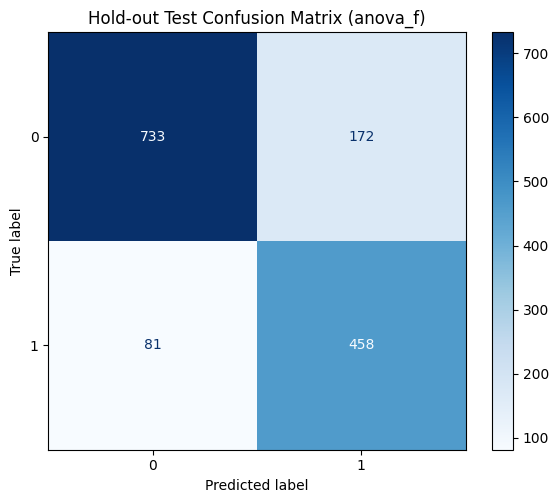

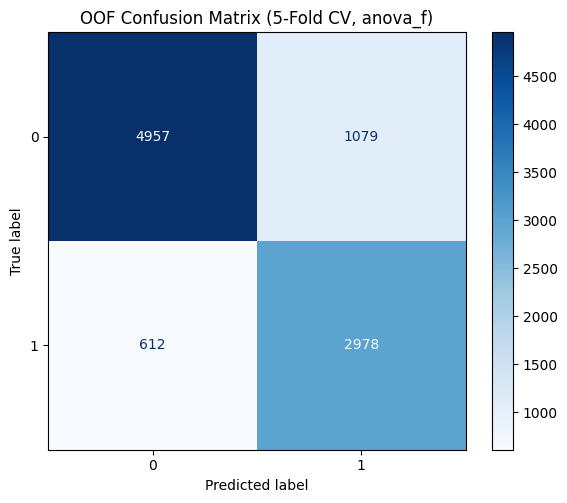

[anova_f] Hold-out accuracy=0.8248, balanced_accuracy=0.8298, f1=0.8270
[anova_f] 5-fold CV accuracy=0.8243 +/- 0.0042
[anova_f] 5-fold CV balanced_accuracy=0.8254 +/- 0.0050
[anova_f] 5-fold CV f1=0.8262 +/- 0.0042


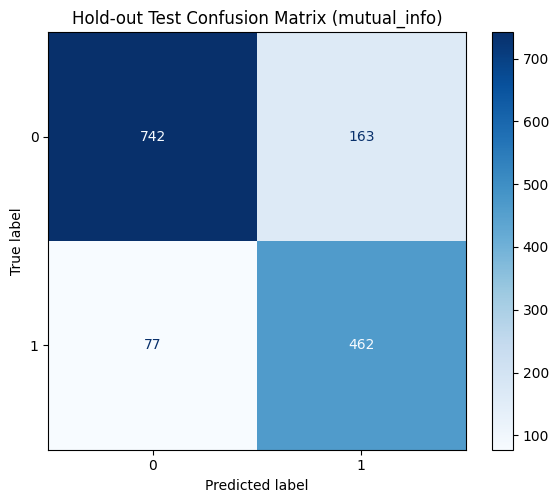

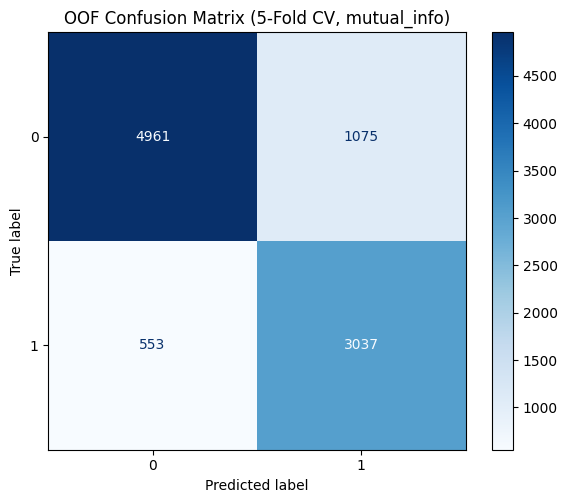

[mutual_info] Hold-out accuracy=0.8338, balanced_accuracy=0.8385, f1=0.8358
[mutual_info] 5-fold CV accuracy=0.8309 +/- 0.0130
[mutual_info] 5-fold CV balanced_accuracy=0.8339 +/- 0.0113
[mutual_info] 5-fold CV f1=0.8328 +/- 0.0126


,method,top_k,holdout_accuracy,holdout_balanced_accuracy,holdout_f1_weighted,cv_accuracy,cv_accuracy_std,cv_balanced_accuracy,cv_balanced_accuracy_std,cv_f1_weighted,cv_f1_weighted_std
0,mutual_info,50,0.833795,0.838516,0.835789,0.830877,0.013044,0.833934,0.011311,0.832784,0.012649
1,anova_f,50,0.824792,0.829833,0.826974,0.824331,0.004214,0.825383,0.005006,0.826152,0.004187


In [28]:
all_results = []

for method_name, score_func in FEATURE_SELECTION_METHODS.items():
    result = run_feature_selection_baseline(
        data=data,
        feature_names=feature_names,
        method_name=method_name,
        score_func=score_func,
    )
    all_results.append(result)

results_df = pd.DataFrame([
    {
        'method': r['method'],
        'top_k': r['top_k'],
        'holdout_accuracy': r['holdout_accuracy'],
        'holdout_balanced_accuracy': r['holdout_balanced_accuracy'],
        'holdout_f1_weighted': r['holdout_f1_weighted'],
        'cv_accuracy': r['cv_accuracy'],
        'cv_accuracy_std': r['cv_accuracy_std'],
        'cv_balanced_accuracy': r['cv_balanced_accuracy'],
        'cv_balanced_accuracy_std': r['cv_balanced_accuracy_std'],
        'cv_f1_weighted': r['cv_f1_weighted'],
        'cv_f1_weighted_std': r['cv_f1_weighted_std'],
    }
    for r in all_results
]).sort_values('cv_balanced_accuracy', ascending=False).reset_index(drop=True)

results_df